# Centralized Model (Baseline)

In [34]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from train import task
from exploration import exploration_utils
import centralized_utils

In [35]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from train import task

from sklearn.metrics import jaccard_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve, average_precision_score, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
from torchvision import models
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
import time
import glob

## Data

In [36]:
import pandas as pd
import glob
import os

In [37]:
hospitals = ['hospital_a', 'hospital_b', 'hospital_c']
hospital_data = {}

patterns = {
    'train': 'train-*.parquet',
    'eval':  'eval-*.parquet',
    'test':  'test*.parquet',
}

for hospital in hospitals:
    data_path = os.path.join('../../data/', hospital)
    hospital_data[hospital] = {}
    
    for split, pattern in patterns.items():
        files = glob.glob(os.path.join(data_path, pattern))
        hospital_data[hospital][split] = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

hospital_data['hospital_d'] = {}
hospital_d_files = glob.glob(os.path.join('../../data/', 'test*.parquet'))
hospital_data['hospital_d']['test'] = pd.concat([pd.read_parquet(f) for f in hospital_d_files], ignore_index=True)

In [38]:
rows = {}

for split in patterns.keys():
    rows[split] = {
        'Hospital A': len(hospital_data['hospital_a'][split]),
        'Hospital B': len(hospital_data['hospital_b'][split]), 
        'Hospital C': len(hospital_data['hospital_c'][split]),
        'Hospital D': len(hospital_data['hospital_d'][split]) if split == 'test' else 0,
    }
    rows[split]['Total'] = sum(rows[split][h] for h in ['Hospital A', 'Hospital B', 'Hospital C', 'Hospital D'])
rows['Total'] = {
    'Hospital A': sum(rows[split]['Hospital A'] for split in ['train', 'eval', 'test']),
    'Hospital B': sum(rows[split]['Hospital B'] for split in ['train', 'eval', 'test']), 
    'Hospital C': sum(rows[split]['Hospital C'] for split in ['train', 'eval', 'test']),
    'Hospital D': sum(rows[split]['Hospital D'] for split in ['train', 'eval', 'test'])
}

rows['Total']['Total'] = sum(rows['Total'][hospital] for hospital in ['Hospital A', 'Hospital B', 'Hospital C', 'Hospital D'])

data_info = pd.DataFrame.from_dict(rows, orient='index')
data_info

,Hospital A,Hospital B,Hospital C,Hospital D,Total
train,5401,3509,3649,0,12559
eval,685,493,495,0,1673
test,1228,588,597,1222,3635
Total,7314,4590,4741,1222,17867


In [39]:
df_train_combined = pd.concat([hospital_data[h]['train'] for h in hospital_data if h != 'hospital_d'], ignore_index=True)
df_val_combined = pd.concat([hospital_data[h]['eval'] for h in hospital_data if h != 'hospital_d'], ignore_index=True)
df_test_combined = pd.concat([hospital_data[h]['test'] for h in hospital_data], ignore_index=True)
len(df_train_combined), len(df_val_combined), len(df_test_combined)

(12559, 1673, 3635)

### Class Imbalance

In [40]:
label_distribution = df_train_combined['label'].explode().value_counts().reset_index()
label_distribution.columns = ['Pathology Label', 'Frequency']
label_distribution['Percentage (%)'] = (label_distribution['Frequency'] / len(df_train_combined) * 100).map(lambda x: f'{x:.2f}')
label_distribution

,Pathology Label,Frequency,Percentage (%)
0,No Finding,3867,30.79
1,Infiltration,3433,27.33
2,Effusion,2919,23.24
3,Atelectasis,2456,19.56
4,Mass,1672,13.31
5,Nodule,1552,12.36
6,Consolidation,1471,11.71
7,Pneumothorax,1422,11.32
8,Pleural_Thickening,1295,10.31
9,Emphysema,913,7.27


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

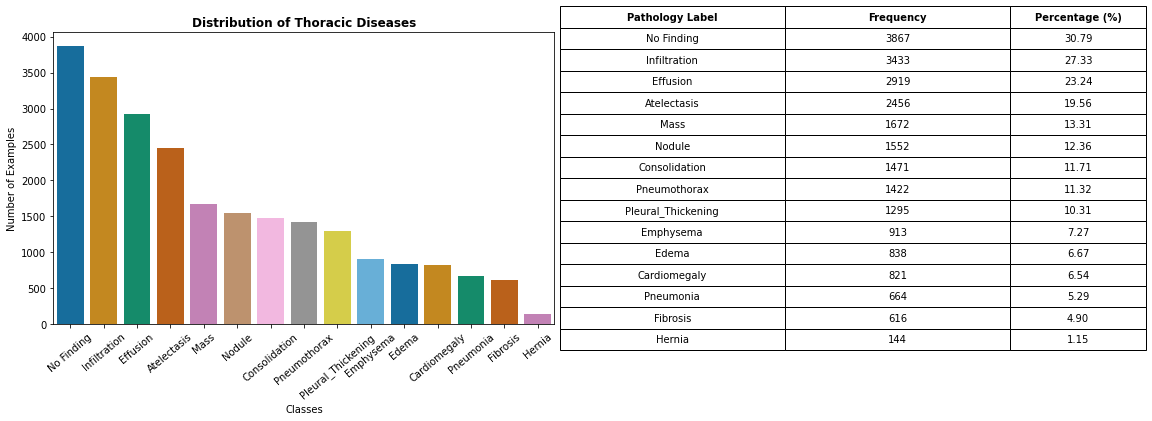

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=label_distribution, x='Pathology Label', y='Frequency', hue='Pathology Label', ax=ax[0], palette='colorblind')
ax[0].set_title('Distribution of Thoracic Diseases').set_weight('bold')
ax[0].set_xlabel('Classes')
ax[0].set_ylabel('Number of Examples')
ax[0].tick_params(axis='x', rotation=40)

table = ax[1].table(cellText=label_distribution.values, cellLoc='center', 
            colLabels=label_distribution.columns, loc='center', colWidths=[0.5, 0.5, 0.3])
table.scale(0.9 ,2)
table[0, 0].get_text().set_weight('bold')
table[0, 1].get_text().set_weight('bold')
table[0, 2].get_text().set_weight('bold')
ax[1].axis('off')
plt.tight_layout()
plt.show();

### Data Visualization (Preprocessing vs. No-preprocessing)

In [43]:
from torchvision import models

Desnet121 requires the following data preprocessing:

In [44]:
weights = models.DenseNet121_Weights.DEFAULT
preprocess_transform = weights.transforms()
preprocess_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [45]:
train_preprocessed = task.XrayDataset(df_train_combined, transform=preprocess_transform)
train_not_preprocessed = task.XrayDataset(df_train_combined, transform=None)

In [46]:
pre_img, pre_label = train_preprocessed[5]
not_img, not_label = train_not_preprocessed[5]

#### Preprocessed

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


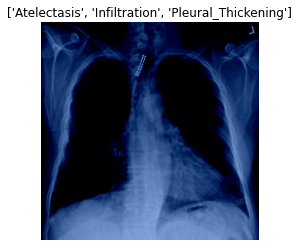

In [47]:
centralized_utils.show_xray(pre_img.permute(1, 2, 0), pre_label)

#### Not Preprocessed

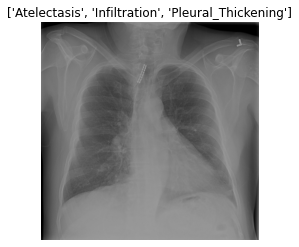

In [48]:
centralized_utils.show_xray(not_img, not_label)

### Weights

In [49]:
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import torch

In [50]:
unique_labels = set(label for labels in df_train_combined['label'] for label in labels)
print(unique_labels)

{'Mass', 'Nodule', 'Pneumonia', 'Hernia', 'Effusion', 'Atelectasis', 'Consolidation', 'Pleural_Thickening', 'Emphysema', 'No Finding', 'Edema', 'Cardiomegaly', 'Pneumothorax', 'Infiltration', 'Fibrosis'}


In [51]:
df_train_combined['label'] = df_train_combined['label'].apply(lambda x: [] if 'No Finding' in x else x)

In [52]:
unique_labels = set(label for labels in df_train_combined['label'] for label in labels)
print(unique_labels) # No Finding not present

{'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Effusion', 'Hernia', 'Atelectasis', 'Consolidation', 'Pleural_Thickening', 'Edema', 'Cardiomegaly', 'Emphysema', 'Infiltration', 'Fibrosis'}


In [53]:
mlb = MultiLabelBinarizer(classes=task.DISEASE_LABELS)
y_np = mlb.fit_transform(df_train_combined['label'])

In [54]:
# Double Checking one-hot encoding is consistent with DISEASE_LABELS
np.array_equal(mlb.classes_, task.DISEASE_LABELS)

True

In [55]:
y = torch.tensor(y_np, dtype=torch.float32)

In [56]:
pos_weights, neg_weights = centralized_utils.calculate_weights(y)
pos_weights, neg_weights

(tensor([ 5.1136, 15.2972,  4.3025,  3.6583,  7.5114,  8.0921, 18.9142,  8.8319,
          8.5377, 14.9869, 13.7558, 20.3880,  9.6981, 87.2153]),
 tensor([1.2431, 1.0699, 1.3028, 1.3762, 1.1536, 1.1410, 1.0558, 1.1277, 1.1327,
         1.0715, 1.0784, 1.0516, 1.1150, 1.0116]))

In [57]:
pos_weights = centralized_utils.calculate_pos_weights(y)
pos_weights

tensor([ 4.1136, 14.2972,  3.3025,  2.6583,  6.5114,  7.0921, 17.9142,  7.8319,
         7.5377, 13.9869, 12.7558, 19.3880,  8.6981, 50.0000])

## Model

In [82]:
class DenseNet121(torch.nn.Module):
    """
    DenseNet121 model with `n_classes` outputs.
    """
    def __init__(self, n_classes, device='cpu'):
        super().__init__()
        self.device = device
        self.densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.densenet.classifier = nn.Identity()
        self.top_network = nn.Sequential(
            nn.Conv2d(1024, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.1), # paper 0.1, maybe try 0.5?
            
            nn.AdaptiveAvgPool2d((3, 3)),
            
            nn.Flatten(),
            nn.Linear(1152, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, n_classes),
            nn.BatchNorm1d(n_classes)
        )
        self.to(self.device)
        
    def layer_summary(self, X_shape):
        X = torch.randn(*X_shape).to(self.device)
        print('---DenseNet121---')
        for layer in self.densenet.features:
            X = layer(X)
            print(layer.__class__.__name__, 'output shape:\t', X.shape)
        print('---Top Network---')
        for layer in self.top_network:
            X = layer(X)
            print(layer.__class__.__name__, 'output shape:\t', X.shape)
            
    def forward(self, X):
        X = self.densenet.features(X)
        X = self.top_network(X)
        return X

#### New Loss Function - Weighted Binary Cross Entropy Loss Function

In [83]:
def weighted_bce_loss(p, y, pos_weights, neg_weights, epsilon=1e-7):
    L = -(pos_weights * y * torch.log(p + epsilon) + neg_weights * (1 - y) * torch.log(1 - p + epsilon))
    return L.mean()

In [84]:
import torch
import time

In [85]:
device = 'cpu'
if torch.cuda.is_available():
    device = torch.device('cuda:0')
print('Running on', device)

Running on cuda:0


In [86]:
n_classes = 14
densenet121 = DenseNet121(n_classes, device=device)

In [87]:
img_shape = pre_img.shape
densenet121.layer_summary((2, *img_shape))

---DenseNet121---
Conv2d output shape:	 torch.Size([2, 64, 112, 112])
BatchNorm2d output shape:	 torch.Size([2, 64, 112, 112])
ReLU output shape:	 torch.Size([2, 64, 112, 112])
MaxPool2d output shape:	 torch.Size([2, 64, 56, 56])
_DenseBlock output shape:	 torch.Size([2, 256, 56, 56])
_Transition output shape:	 torch.Size([2, 128, 28, 28])
_DenseBlock output shape:	 torch.Size([2, 512, 28, 28])
_Transition output shape:	 torch.Size([2, 256, 14, 14])
_DenseBlock output shape:	 torch.Size([2, 1024, 14, 14])
_Transition output shape:	 torch.Size([2, 512, 7, 7])
_DenseBlock output shape:	 torch.Size([2, 1024, 7, 7])
BatchNorm2d output shape:	 torch.Size([2, 1024, 7, 7])
---Top Network---
Conv2d output shape:	 torch.Size([2, 256, 7, 7])
BatchNorm2d output shape:	 torch.Size([2, 256, 7, 7])
ReLU output shape:	 torch.Size([2, 256, 7, 7])
Conv2d output shape:	 torch.Size([2, 128, 7, 7])
BatchNorm2d output shape:	 torch.Size([2, 128, 7, 7])
ReLU output shape:	 torch.Size([2, 128, 7, 7])
Dropout

## Training

In [88]:
def train_stage1(model, train_loader, val_loader, device, epochs, pos_weight=None, 
                 eta=1e-3, weight_decay=4e-3):
    for param in model.densenet.parameters():
        param.requires_grad = False
    
    optimizer = torch.optim.AdamW(model.top_network.parameters(),
                                 lr=eta,
                                 weight_decay=weight_decay)
    return train(model, train_loader, val_loader, device, epochs, optimizer, pos_weight)

def train_stage2(model, train_loader, val_loader, device, epochs, pos_weight=None, 
                 eta=1e-5, weight_decay=4e-3, eta_min=1e-7):
    for param in model.densenet.parameters():
        param.requires_grad = True
        
    optimizer = torch.optim.AdamW(model.parameters(),
                                 lr=eta,
                                 weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=eta_min)
    return train(model, train_loader, val_loader, device, epochs, optimizer, pos_weight, scheduler)
    

In [89]:
def train(model, train_loader, val_loader, device, epochs, optimizer, pos_weight=None, scheduler=None):
    """
    Training loop that outputs loss, training time, and peak memory usage.
    """
    if pos_weight is None:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    total_train_loss = []
    total_val_loss = []
    
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    total_training_time = 0.0
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f'Train - Epoch {epoch+1}/{epochs}')

        train_start = time.time()
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
        
            logits = model(images)
            loss = criterion(logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        if scheduler is not None:
            scheduler.step()
            
        train_time = time.time() - train_start
        total_training_time += train_time
        avg_train_loss = train_loss / len(train_loader)
        total_train_loss.append(avg_train_loss)

        # Validation
        val_loss = 0.0
        model.eval()
        eval_pbar = tqdm(val_loader, desc=f'Val - Epoch {epoch+1}/{epochs}')
        with torch.no_grad():
            for images, labels in eval_pbar:
                images, labels = images.to(device), labels.to(device)
                
                logits = model(images)
                loss = criterion(logits, labels)
                    
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        total_val_loss.append(avg_val_loss)
        
        print(f'Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Time: {train_time:.2f}s')

    if torch.cuda.is_available():
        peak_memory_usage = torch.cuda.max_memory_allocated(device) / (1024 ** 3)
    else:
        peak_memory_usage = None
    
    return total_train_loss, total_val_loss, total_training_time, peak_memory_usage

In [90]:
from torch.utils.data import Dataset, DataLoader

In [91]:
n_epochs1 = 5
n_epochs2 = 15 # 20
batch_size = 64
eta1 = 1e-3
eta2 = 1e-5
eta_min = 1e-7
weight_decay = 4e-3

n_classes = 14
densenet121 = DenseNet121(n_classes, device=device)
pos_weights = pos_weights.to(device)

train_dataset = task.XrayDataset(df_train_combined, transform=preprocess_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = task.XrayDataset(df_val_combined, transform=preprocess_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [92]:
train1_loss, val1_loss, time1, memory1 = train_stage1(
    densenet121, train_loader, val_loader, device, n_epochs1, pos_weights, eta1, weight_decay
);

Val - Epoch 1/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.02s/it]


Epoch 1 | Train Loss: 1.1248 | Val Loss: 1.0889 | Train Time: 208.91s


Val - Epoch 2/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.03s/it]


Epoch 2 | Train Loss: 1.0248 | Val Loss: 1.0809 | Train Time: 213.22s


Val - Epoch 3/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.03s/it]


Epoch 3 | Train Loss: 0.9631 | Val Loss: 1.0675 | Train Time: 209.91s


Val - Epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.02s/it]


Epoch 4 | Train Loss: 0.9046 | Val Loss: 1.0784 | Train Time: 211.42s


Val - Epoch 5/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.02s/it]

Epoch 5 | Train Loss: 0.8366 | Val Loss: 1.0983 | Train Time: 211.89s


In [ ]:
train2_loss, val2_loss, time2, memory2 = train_stage2(
    densenet121, train_loader, val_loader, device, n_epochs2, pos_weights, eta2, weight_decay, eta_min
);

Val - Epoch 1/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.02s/it]


Epoch 1 | Train Loss: 0.7484 | Val Loss: 1.0969 | Train Time: 292.13s


Val - Epoch 2/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.02s/it]


Epoch 2 | Train Loss: 0.6994 | Val Loss: 1.0992 | Train Time: 295.72s


Val - Epoch 3/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.02s/it]


...

Val - Epoch 5/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.03s/it]


Epoch 5 | Train Loss: 0.6286 | Val Loss: 1.1187 | Train Time: 292.21s


Val - Epoch 6/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:27<00:00,  1.02s/it]


Epoch 6 | Train Loss: 0.6137 | Val Loss: 1.1179 | Train Time: 293.16s


Train - Epoch 7/15:  59%|████████████████████████████████████████████████████████████████████████████████                                                        | 116/197 [02:52<01:59,  1.48s/it]

## Evaluation

In [37]:
def threshold_tuning(model, val_loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            logits = model(images)

            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    num_classes = all_labels.shape[1]
    best_thresholds = []
    thresholds = np.linspace(0, 1, 101)
    for label in range(num_classes):
        best_t = 0.5
        best_score = -1

        for t in thresholds:
            preds = (all_probs[:, label] >= t).astype(int) # T/F -> 0/1
            score = f1_score(all_labels[:, label], preds)

            if score > best_score:
                best_score = score
                best_t = t
        best_thresholds.append(best_t)
    return np.array(best_thresholds) 

### Training Loss Curve

In [39]:
def plot_loss(loss_train, loss_val):
    """
    Plot loss curve of train set.
    """
    plt.figure(figsize=(5,3))
    plt.plot(range(1, len(loss_train)+1), loss_train, label='Training Loss')
    plt.plot(range(1, len(loss_val)+1), loss_val, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='best')
    plt.show()

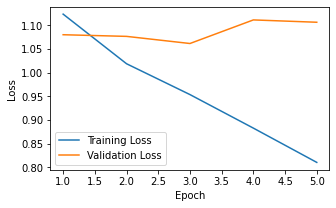

In [40]:
plot_loss(train1_loss, val1_loss)

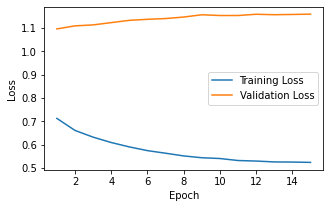

In [41]:
plot_loss(train2_loss, val2_loss)

In [42]:
best_thresholds = threshold_tuning(densenet121, val_loader)

In [43]:
best_thresholds

array([0.45, 0.75, 0.51, 0.43, 0.49, 0.55, 0.49, 0.56, 0.52, 0.63, 0.69,
       0.75, 0.51, 0.67])

### Metrics

In [46]:
from sklearn.metrics import jaccard_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve, average_precision_score, classification_report
import matplotlib.pyplot as plt
from torchvision import models
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
import time
import glob
import os

In [47]:
def evaluate(model, test_loader, device, thresholds):
    """
    Evaluates model using Jaccard, F1, Recall, Precision, ROC-AUC, Per-class ROC-AUC.
    """
    actual = []
    pred = []
    probs_all = []
    
    model.eval()
    pbar = tqdm(test_loader, desc=f"Evaluating")
    thresholds = torch.tensor(thresholds, device=device).view(1, -1)
    for (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            logits = model(images)

            probs = torch.sigmoid(logits)

            y_pred = (probs > thresholds).int().cpu().numpy()
            y_actual = labels.cpu().numpy()
    
            actual.append(y_actual)
            pred.append(y_pred)
            probs_all.append(probs.cpu().numpy())
    actual = np.vstack(actual)
    pred = np.vstack(pred)
    probs_all = np.vstack(probs_all)
            
    jaccard = jaccard_score(actual, pred, average='samples', zero_division=0)
    per_class_accuracy = (pred == actual).mean(axis=0) * 100
    per_class_accuracy_dict = {
        disease: acc for disease, acc in zip(task.DISEASE_LABELS, per_class_accuracy)
    }
    f1 = f1_score(actual, pred, average='macro', zero_division=0)
    per_class_f1 = f1_score(actual, pred, average=None, zero_division=0)
    per_class_f1_dict = {
        disease: f1 for disease, f1 in zip(task.DISEASE_LABELS, per_class_f1)
    }
    recall = recall_score(actual, pred, average='macro', zero_division=0)
    precision = precision_score(actual, pred, average='macro', zero_division=0)
    roc_auc = roc_auc_score(actual, probs_all, average='macro')
    per_class_auc = roc_auc_score(actual, probs_all, average=None)
    per_class_auc_dict = {
        disease: auc for disease, auc in zip(task.DISEASE_LABELS, per_class_auc)
    }
    aucpr = average_precision_score(actual, probs_all, average='macro')
    per_class_aucpr = average_precision_score(actual, probs_all, average=None)
    per_class_aucpr_dict = {
        disease: aucpr for disease, aucpr in zip(task.DISEASE_LABELS, per_class_aucpr)
    }

    report = classification_report(actual, pred, target_names=task.DISEASE_LABELS)

    print("TYPE:", type(actual))
    
    results = {
        'Jaccard Similarity': jaccard,
        'per_class_acc': per_class_accuracy_dict,
        'F1_score': f1, 
        'per_class_f1': per_class_f1_dict,
        'Recall': recall,
        'Precision': precision,
        'roc_auc': roc_auc,
        'per_class_auc': per_class_auc_dict,
        'aucpr': aucpr,
        'per_class_aucpr': per_class_aucpr_dict,
        'actual': actual,
        'probs': probs_all,
        'classification_report': report
    }
    return results

In [48]:
test_dataset = task.XrayDataset(df_test_combined, transform=preprocess_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

results = evaluate(densenet121, test_loader, device, best_thresholds);

Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 57/57 [00:59<00:00,  1.05s/it]

TYPE: <class 'numpy.ndarray'>



/usr/local/python-env/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/python-env/py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [49]:
print(results['classification_report'])

                    precision    recall  f1-score   support

       Atelectasis       0.24      0.62      0.34       623
      Cardiomegaly       0.22      0.32      0.26       209
          Effusion       0.37      0.64      0.47       746
      Infiltration       0.30      0.73      0.42       853
              Mass       0.15      0.48      0.23       390
            Nodule       0.15      0.43      0.23       385
         Pneumonia       0.05      0.36      0.09       135
      Pneumothorax       0.21      0.41      0.28       331
     Consolidation       0.16      0.52      0.25       358
             Edema       0.16      0.48      0.24       184
         Emphysema       0.22      0.32      0.26       182
          Fibrosis       0.10      0.18      0.13       133
Pleural_Thickening       0.11      0.47      0.17       257
            Hernia       0.01      0.15      0.03        13

         micro avg       0.20      0.54      0.29      4799
         macro avg       0.18      0.4

In [50]:
per_class_auc = results['per_class_auc']

for key, val in per_class_auc.items():
    print(f'{key:20s} {val:4f}')

Atelectasis          0.643605
Cardiomegaly         0.704906
Effusion             0.741958
Infiltration         0.646326
Mass                 0.597330
Nodule               0.621049
Pneumonia            0.571953
Pneumothorax         0.681263
Consolidation        0.631247
Edema                0.765948
Emphysema            0.715969
Fibrosis             0.640525
Pleural_Thickening   0.626273
Hernia               0.628425


In [51]:
per_class_acc = results['per_class_acc']

for key, val in per_class_acc.items():
    print(f'{key:20s} {val:4f}%')

Atelectasis          58.927098%
Cardiomegaly         89.683631%
Effusion             70.233838%
Infiltration         52.984869%
Mass                 64.456671%
Nodule               68.665750%
Pneumonia            71.279230%
Pneumothorax         80.385144%
Consolidation        69.105915%
Edema                84.731774%
Emphysema            90.866575%
Fibrosis             91.251719%
Pleural_Thickening   68.225585%
Hernia               95.983494%


In [52]:
per_class_f1 = results['per_class_f1']

for key, val in per_class_f1.items():
    print(f'{key:20s} {val:4f}')

Atelectasis          0.342580
Cardiomegaly         0.260355
Effusion             0.466995
Infiltration         0.421658
Mass                 0.226347
Nodule               0.226748
Pneumonia            0.085814
Pneumothorax         0.277609
Consolidation        0.247823
Edema                0.242838
Emphysema            0.262222
Fibrosis             0.131148
Pleural_Thickening   0.172043
Hernia               0.026667


In [53]:
from sklearn.metrics import jaccard_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve, average_precision_score, RocCurveDisplay

In [54]:
type(results['actual'])

numpy.ndarray

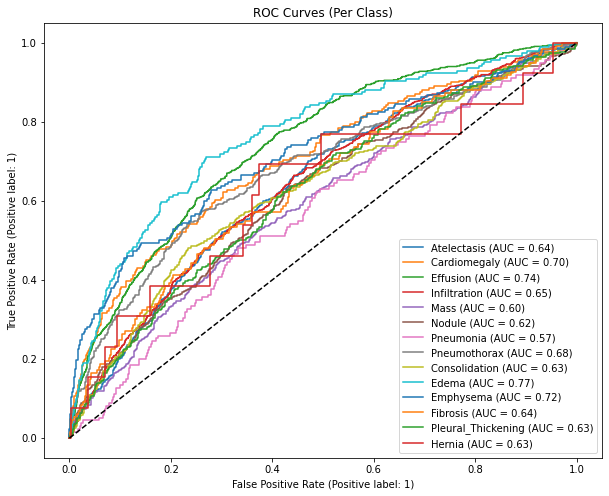

In [55]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, disease in enumerate(task.DISEASE_LABELS):
    RocCurveDisplay.from_predictions(
        results['actual'][:, i],
        results['probs'][:, i],
        name=disease,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="black")
ax.set_title("ROC Curves (Per Class)")
plt.show()

In [56]:
results['Precision']

0.1750015704419631

In [57]:
results['Recall']

0.4376454412557908